<a href="https://colab.research.google.com/github/mohitjainak15-lab/ml_in_astro_csot/blob/main/submissions/mohit-jain/week1/week1_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from pathlib import Path
# RAW_ROOT = Path("raw_ml_astro")
# IMAGES_DIR = RAW_ROOT / "images_gz2"
# DATA_ROOT = Path("ml_astronomy")
# LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

# from google.colab import files
# files.upload()
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !pip -q install kaggle pandas
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# !unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}
# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}
# !wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
# !gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

# print("RAW_ROOT   =", RAW_ROOT)
# print("IMAGES_DIR =", IMAGES_DIR)
# print("DATA_ROOT  =", DATA_ROOT)

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# from pathlib import Path

# RAW_ROOT = Path("/content/drive/MyDrive/raw_ml_astro")
# !unzip -q galaxy-zoo-2-images.zip -d {RAW_ROOT}

In [3]:
# from pathlib import Path
# from google.colab import drive
# drive.mount('/content/drive')
# RAW_ROOT = Path("/content/drive/MyDrive/raw_ml_astro")
# LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

# !wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
# !gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

Mounted at /content/drive
torch.Size([3, 64, 64])
torch.float32
0
{'elliptical': 0, 'spiral': 1}
38
['elliptical', 'spiral']
torch.Size([32, 3, 64, 64])
torch.Size([32])


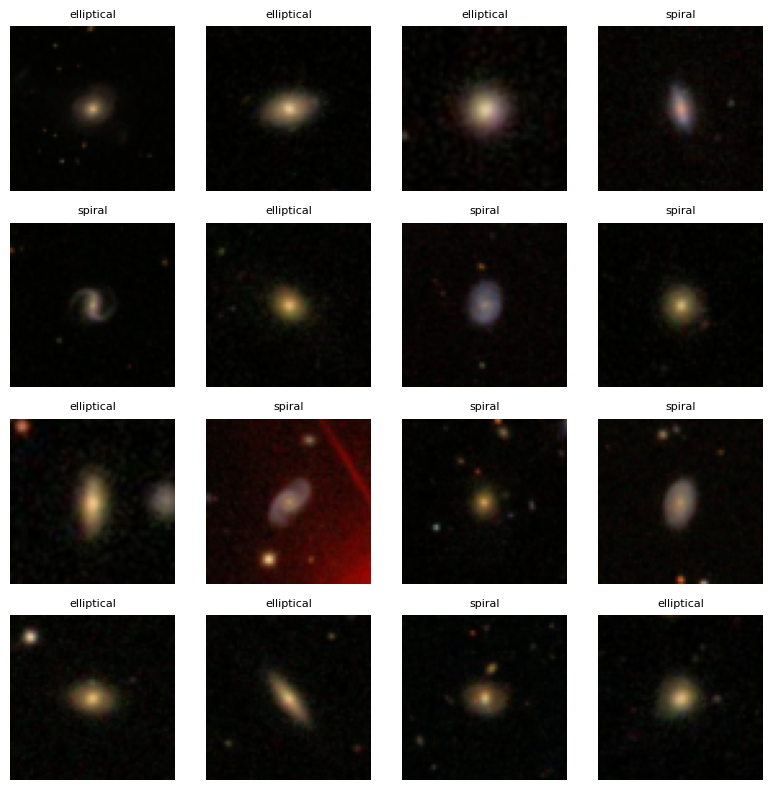

In [4]:
import pandas as pd
import os
from pathlib import Path
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

RAW_ROOT=Path("/content/drive/MyDrive/raw_ml_astro")
IMAGES_DIR=RAW_ROOT/"images_gz2"
DATA_ROOT=Path("/content/drive/MyDrive/please")

def high_level_label(gz2_class: str):
    if not gz2_class or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("S"):
        return "spiral"
    if gz2_class.startswith("SB"):
        return "spiral barred"
    return None

import shutil

shutil.rmtree(DATA_ROOT, ignore_errors=True)
def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    c = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        # print(df["label"].value_c(dropna=False))

        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
              shutil.copy2(src, dst)
              linked += 1
        c[label] = linked
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    # print("After merge:", len(df))
    # print(df["gz2_class"].head(20))
    # print(os.listdir(images_dir)[:10])
    # print(os.listdir(IMAGES_DIR)[:20])

    return c

PER_CLASS = 200
c= build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
# print(IMAGES_DIR)
# print(IMAGES_DIR.exists())

# print((RAW_ROOT / "gz2_filename_mapping.csv").exists())
# print((RAW_ROOT / "gz2_hart16.csv").exists())
# print("Symlinked per class:", c)
# print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))
trans=transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor(),transforms.Normalize([0.5]*3,[0.5]*3)])
data=datasets.ImageFolder(root=DATA_ROOT,transform=trans)
image,label=data[0]
print(image.shape)
print(image.dtype)
print(label)
print(data.class_to_idx)
print(len(data))
print(data.classes)
# test=DataLoader(data,batch_size=300,shuffle=False,pin_memory=True,num_workers=2)
# i,l=next(iter(test))
# print(l.shape)
# print((next(iter(test))))
trainer=DataLoader(data,batch_size=32,shuffle=True,num_workers=2, pin_memory=True)
images,labels=next(iter(trainer))
print(images.shape)
print(labels.shape)

images_show = images * 0.5 + 0.5
# grid = make_grid(images_show[:16], nrow=4)

# plt.figure(figsize=(8, 8))
# plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
# plt.axis("off")
# plt.title("A batch of galaxies")
# plt.show()

# print("Labels:", [data.classes[i] for i in labels[:16].tolist()])
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images_show[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.set_title(data.classes[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [5]:
# !ls -l /content/drive/MyDrive/ml_astronomy/spiral | head

In [6]:
# !mv /content/drive/MyDrive/raw_ml_astro/images_gz2/images/* \
#      /content/drive/MyDrive/raw_ml_astro/images_gz2/
# !rmdir /content/drive/MyDrive/raw_ml_astro/images_gz2/images
# !ls /content/drive/MyDrive/raw_ml_astro/images_gz2 | head

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')
# !ls /content/drive/MyDrive

1.What was the most confusing part of setup or the data pipeline? How did you resolve it?
correctly assembling all the data
2.Pick one galaxy class (E / S / S0 / Irr) and describe what features a CNN might need to detect to recognise it.
elliptical ones have bright center and are closed circular
3.After plotting real batches: which two classes do you think will be hardest for a model to tell apart, and why?
lenticular from others
4.Why do we spend so much effort on the data pipeline before building any model?
the data given to us is not uniform and without the correct transforms it would not be possible to train a good model